### Bayesian MC dropout query strategies

Bayesian query strategies use Monte Carlo (MC) dropout to approximate uncertainty in deep learning models. This works by computing multiple forward passes through a neural network with the dropout layers activated. For this example we are going to use a subset of [_MNIST_](https://archive.ics.uci.edu/dataset/683/mnist+database+of+handwritten+digits) dataset, loaded from _sklearn_.

In [1]:
import numpy as np
import torch
from skorch import NeuralNetClassifier

from activelearning.AL_cycle import plot_results, strategy_comparison
from activelearning.queries.bayesian.mc_max_entropy import mc_max_entropy
from activelearning.queries.representative.kmeans_query import query_kmeans_foreach, query_kmeans
from activelearning.queries.representative.coreset_query import query_coreset
from activelearning.queries.representative.density_query import query_density
from activelearning.queries.representative.diversity_query import query_diversity
from activelearning.queries.representative.probcover_query import query_probcover
from activelearning.queries.representative.random_query import query_random

torch.manual_seed(123)
np.random.seed(123)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import sys
import os
import numpy as np
import torch

from embeddings.masked_embedding import MaskedReconstruction, MultimodalMAE

print(os.getcwd())

PROJECT_ROOT = os.path.abspath("../..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from al_data_process.data_preprocess import create_windowed_ts, map_class_label_to_idx
from al_data_process.dataset import stratified_sampling, stratified_sampling_train_val

window_length = 0.4
overlap = 0.25

invalid_classes = [14]
Xt_acc, Xt_gyr, Xt_mag, Xt_mic, y_org_label = create_windowed_ts(data_path="../../tool-tracking-data/",
                                                                     tool="electric_screwdriver",
                                                                     invalid_classes=invalid_classes,
                                                                     window_length = window_length,
                                                                     overlap = overlap)

all_classes, counts = np.unique(y_org_label, return_counts=True)

Xt_acc = Xt_acc[:, :, 1:].astype(np.float32)
Xt_gyr = Xt_gyr[:, :, 1:].astype(np.float32)
Xt_mag = Xt_mag[:, :, 1:].astype(np.float32)
Xt_mic = Xt_mic[:, :, 1:].astype(np.float32)

y = map_class_label_to_idx(y_org_label)

train_set, test_set = stratified_sampling_train_val(torch.from_numpy(Xt_acc),
                                                  torch.from_numpy(Xt_gyr),
                                                  torch.from_numpy(Xt_mag),
                                                  torch.from_numpy(Xt_mic),
                                                  torch.tensor(y))


X_pool = np.empty(len(train_set), dtype=object)
y_pool = np.empty(len(train_set))
for i in range(len(train_set)):
    X_pool[i] = train_set[i][0]
    y_pool[i] = train_set[i][1]


X_test = np.empty(len(test_set), dtype=object)
y_test = np.empty(len(test_set))
for i in range(len(test_set)):
    X_test[i] = test_set[i][0]
    y_test[i] = test_set[i][1]


# model = MultimodalMAE().to(device)
# recon = MaskedReconstruction().to(device)

# checkpoint = torch.load("../embeddings/multimodal_mae.pth", map_location=device)

# model.load_state_dict(checkpoint['model_state_dict'])
# recon.load_state_dict(checkpoint['recon_state_dict'])

# model.eval()
# recon.eval()

# print("Models loaded and ready for inference.")

# @torch.no_grad()
# def extract_embedding(acc, gyr, mag, mic):
#     model.eval()
#     acc, gyr, mag, mic = (
#         acc.to(device),
#         gyr.to(device),
#         mag.to(device),
#         mic.to(device).squeeze()
#     )
#     z, _ = model(acc, gyr, mag, mic)
#     return z.cpu()


# embeddings = []
# for acc, gyr, mag, mic in X_pool:
#     z = extract_embedding(acc, gyr, mag, mic)
#     embeddings.append(z)

# X_pool_embeddings = np.array(embeddings)

/proj/ciptmp/du74qapi/tool-tracking/active-learning/examples
[INFO] Preparing data from:
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716


[INFO] Read data:   0%|          | 0/16 [00:00<?, ?it/s]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-03-102.291.csv) and from the timestamps differ by 0.001Hz



[INFO] Read data:  12%|█▎        | 2/16 [00:00<00:03,  3.66it/s, file=MIC-03-8000.csv]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-01-155.087.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-03-102.291.csv) and from the timestamps differ by 0.001Hz



...

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-02-102.291.csv) and from the timestamps differ by 0.001Hz



[INFO] Read annotation: 100%|██████████| 16/16 [00:02<00:00,  6.83it/s, file=data-03.annotation]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-02-154.679.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-04-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-02-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/

[INFO] Read annotation: 100%|██████████| 16/16 [00:02<00:00,  5.60it/s, file=data-02.annotation]


[INFO] Finished with 4 measurement(s).
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
Segment: 100%|██████████| 19380/19380 [00:00<00:00, 44672.02it/s]
[2 3 4 5 6 7 8] [ 546  234  199   89   50   59 3606]
count_1_14: 3, count_invalid_classes: 8, count_maj_vote: 46, count_diff_label: 5


We evaluate the performance of the VGG classifier that we are going to use on the complete training set. This will serve as reference metric for the active learning query strategies, as we want to reach the same accuracy but with less labeled data.

In [4]:
num_lstm_layers = 1
hidden_size = 32
dropout_p = 0.3
num_classes = 7
lr=2e-3
batch_size=16
max_epochs=100

In [5]:
from model.lstm_classif import LSTM_CLASSIF
from sklearn.metrics import f1_score
from skorch.dataset import CVSplit
from skorch.callbacks import EpochScoring, Checkpoint


def compute_class_weights_from_labels(y, beta=0.999):
    """
    Compute effective number class weights directly from labels.

    Args:
        y: array-like, shape (num_samples,)
           Class labels (int or float, discrete)
        beta: float, smoothing factor

    Returns:
        weights: np.array, shape (num_classes,)
    """
    classes, counts = np.unique(y, return_counts=True)
    classes = classes.astype(int)

    counts = counts.astype(np.float32)
    counts = np.maximum(counts, 1.0)

    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num

    weights = weights / weights.mean()

    num_classes = int(np.max(classes)) + 1
    full_weights = np.zeros(num_classes, dtype=np.float32)
    full_weights[classes] = weights

    return full_weights


class_weights = compute_class_weights_from_labels(y_pool, beta=0.999)
class_weights_tensor = torch.from_numpy(class_weights).float()


def collate_fn(batch):
    x_batch, y_batch = zip(*batch)  # x_batch = list of tuples, y_batch = list of labels

    acc, gyr, mag, mic = zip(*x_batch)  # each is a tuple of tensors

    acc = torch.stack(acc, dim=0)  # shape: (batch, time, features)
    gyr = torch.stack(gyr, dim=0)
    mag = torch.stack(mag, dim=0)
    mic = torch.stack(mic, dim=0)

    if isinstance(y_batch[0], torch.Tensor):
        y_batch = torch.stack(y_batch).long()  # works if labels are 0-dim tensors
    else:
        y_batch = torch.tensor(y_batch, dtype=torch.long)


    return (acc, gyr, mag, mic), y_batch


classifier = NeuralNetClassifier(
    LSTM_CLASSIF(input_size=3, hidden_size=hidden_size, num_layers=num_lstm_layers, num_classes=num_classes,
                             dropout_p=dropout_p),
    criterion=torch.nn.CrossEntropyLoss,
    criterion__weight=class_weights_tensor,
    lr=2e-3,
    batch_size=16,
    iterator_train__collate_fn=collate_fn,
    iterator_valid__collate_fn=collate_fn,
    optimizer=torch.optim.Adam,
    train_split=None,
    max_epochs=max_epochs,
    device=device,
    # train_loss_best=True,
)


f1_cb = EpochScoring(
    scoring='f1_macro',      # sklearn scorer name
    lower_is_better=False,
    name='valid_f1',         # metric name in history
    on_train=False,          # compute on validation set
)

checkpoint = Checkpoint(
    monitor='valid_f1_best',
    # load_best=True,
    f_params='best_weights.pt',
)


# classifier = NeuralNetClassifier(
#     LSTM_CLASSIF(
#         input_size=3,
#         hidden_size=hidden_size,
#         num_layers=num_lstm_layers,
#         num_classes=num_classes,
#         dropout_p=dropout_p,
#     ),
#     criterion=torch.nn.CrossEntropyLoss,
#     criterion__weight=class_weights_tensor,
#     optimizer=torch.optim.Adam,
#     lr=lr,
#     batch_size=batch_size,
#     max_epochs=max_epochs,
#     device=device,

#     # train_split=ValidSplit(0.2, stratified=True),
#     # train_split=CVSplit(0.2, stratified=True),
#     train_split=CVSplit(0.15 / 0.85, stratified=True, random_state=42),

#     iterator_train__collate_fn=collate_fn,
#     iterator_valid__collate_fn=collate_fn,

#     callbacks=[f1_cb, checkpoint],
# )

classifier.fit(X_pool, y_pool)

# classifier.load_params(f_params='best_weights.pt')

goal_acc = classifier.score(X_test, y_test)

y_pred = classifier.predict(X_test)
# print(y_pred.shape)
goal_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Goal Accuracy: {goal_acc}")
print(f"Goal F1 Score: {goal_f1}")

  epoch    train_loss     dur
-------  ------------  ------
      1        1.4046  2.2468
      2        1.0812  2.4202
      3        0.9594  2.3598
      4        0.8629  2.3573
      5        0.8017  2.3354
      6        0.7128  2.3528
      7        0.6615  2.3657
      8        0.5956  2.0838
      9        0.6355  2.3222
     10        0.5867  2.4018
     11        0.5794  2.3919
     12        0.5366  2.3136
     13        0.5116  2.4142
     14        0.4878  2.4999
     15        0.5013  2.3006
     16        0.4606  2.3233
     17        0.4423  2.3346
     18        0.4242  2.3356
     19        0.4159  2.3266
     20        0.4253  2.3491
     21        0.4105  2.3518
     22        0.3799  2.3667
     23        0.3847  2.3439
     24        0.3745  2.3584
     25        0.4091  2.6352
     26        0.4194  2.3087
     27        0.3908  2.3441
     28        0.3622  2.3831
     29        0.3186  2.0532
     30        0.3379  1.9601
     31        0.3593  1.8933
     32   

In [6]:
n_init_samples = 100 # number of initial training samples
selected_idx = np.random.choice(len(X_pool), size=n_init_samples, replace=False)

X_initial = X_pool[selected_idx]
y_initial = y_pool[selected_idx]
# X_initial_emb = X_pool_embeddings[selected_idx]

X_pool = np.delete(X_pool, selected_idx, axis=0)
y_pool = np.delete(y_pool, selected_idx, axis=0)
# X_pool_embeddings = np.delete(X_pool_embeddings, selected_idx, axis=0)

To compare how different query strategies perform, we can use the *strategy_comparison* function and pass the strategies to be used. We can also pass more than one number of instances, to check whether a different batch size influences performance. *plot_results* can be used to immediatly plot the output from *strategy_comparison*, or a custom graph can be created from the scores data frame.

In [ ]:


n_instances = [100]
goal_metric = "f1"
# goal_metric = "acc"

classifier = NeuralNetClassifier(
    LSTM_CLASSIF(input_size=3, hidden_size=hidden_size, num_layers=num_lstm_layers, num_classes=num_classes,
                             dropout_p=dropout_p),
    criterion=torch.nn.CrossEntropyLoss,
    # criterion__weight=class_weights_tensor,
    lr=2e-3,
    batch_size=16,
    iterator_train__collate_fn=collate_fn,
    iterator_valid__collate_fn=collate_fn,
    optimizer=torch.optim.Adam,
    train_split=None,
    max_epochs=max_epochs,
    device=device,
)


f1_cb_al = EpochScoring(
    scoring='f1_macro',      # sklearn scorer name
    lower_is_better=False,
    name='valid_f1',         # metric name in history
    on_train=False,          # compute on validation set
)

checkpoint_al = Checkpoint(
    monitor='valid_f1_best',
    # load_best=True,
    f_params='best_weights.pt',
)

# classifier = NeuralNetClassifier(
#     LSTM_CLASSIF(
#         input_size=3,
#         hidden_size=hidden_size,
#         num_layers=num_lstm_layers,
#         num_classes=num_classes,
#         dropout_p=dropout_p,
#     ),
#     criterion=torch.nn.CrossEntropyLoss,
#     # criterion__weight=class_weights_tensor,
#     optimizer=torch.optim.Adam,
#     lr=lr,
#     batch_size=batch_size,
#     max_epochs=max_epochs,
#     device=device,

#     # Use stratified validation split
#     # train_split=ValidSplit(0.2, stratified=True),
#     train_split=CVSplit(0.15 / 0.85),

#     iterator_train__collate_fn=collate_fn,
#     iterator_valid__collate_fn=collate_fn,

#     callbacks=[f1_cb_al, checkpoint_al],
# )



# classifier.get_default_callbacks()
# classifier.callbacks

scores = strategy_comparison(
    X_train=X_initial,
    y_train=y_initial,
    # X_pool=X_pool_embeddings,
    X_pool=X_pool,
    y_pool=y_pool,
    X_test=X_test,
    y_test=y_test,
    # X_train_org=X_initial,
    # classifier="nnet_bo",
    classifier=classifier,
    # query_type="diversity",
    # query_strategies=[mc_bald, mc_max_entropy, mc_max_varratios, query_random, mc_max_meanstd],
    # query_strategies=[query_coreset, query_kmeans_foreach, query_density, query_diversity, query_probcover, query_random],
    query_strategies=[query_random],
    K=7,
    # n_instances=[32],
    n_instances=n_instances,
    # goal_acc=goal_acc,
    goal_metric=goal_metric, 
    goal_metric_val = goal_f1 if goal_metric == "f1" else goal_acc
    # max_epochs=15,
)

  epoch    train_loss     dur
-------  ------------  ------
      1        1.8879  0.0646


      2        1.4569  0.0593
      3        1.0576  0.0662
      4        1.0350  0.0656
      5        0.8772  0.0658
      6        0.8411  0.0629
      7        0.8316  0.0687
      8        0.7881  0.0685
      9        0.6653  0.0697
     10        0.6284  0.0677
     11        0.6204  0.0735
     12        0.5667  0.0780
     13        0.6033  0.0634
     14        0.5641  0.0573
     15        0.6061  0.0698
     16        0.5157  0.0691
     17        0.5223  0.0626
     18        0.5031  0.0577
     19        0.5271  0.0613
     20        0.4872  0.0600
     21        0.4801  0.0630
     22        0.4587  0.0674
     23        0.4726  0.0589
     24        0.3961  0.0650
     25        0.4125  0.0726
     26        0.4078  0.0569
     27        0.3877  0.0582
     28        0.3672  0.0643
     29        0.3668  0.0617
     30        0.3950  0.0670
     31        0.3657  0.0596
     32        0.3662  0.0750
     33        0.3128  0.0684
     34        0.2749  0.0570
     35   

[    density accuracy  density f1 score  density inst
0           0.799443          0.326734           100
1           0.813370          0.346514           200
2           0.791086          0.317060           300
3           0.789694          0.336028           400
4           0.795265          0.316075           500
5           0.782730          0.335830           600
6           0.779944          0.357499           700
7           0.785515          0.322344           800
8           0.807799          0.332934           900
9           0.831476          0.395199          1000
10          0.820334          0.383309          1100
11          0.835655          0.407421          1200
12          0.848189          0.477097          1300
13          0.845404          0.458921          1400
14          0.848189          0.441971          1500
15          0.856546          0.475245          1600
16          0.873259          0.450641          1700
17          0.839833          0.429020       

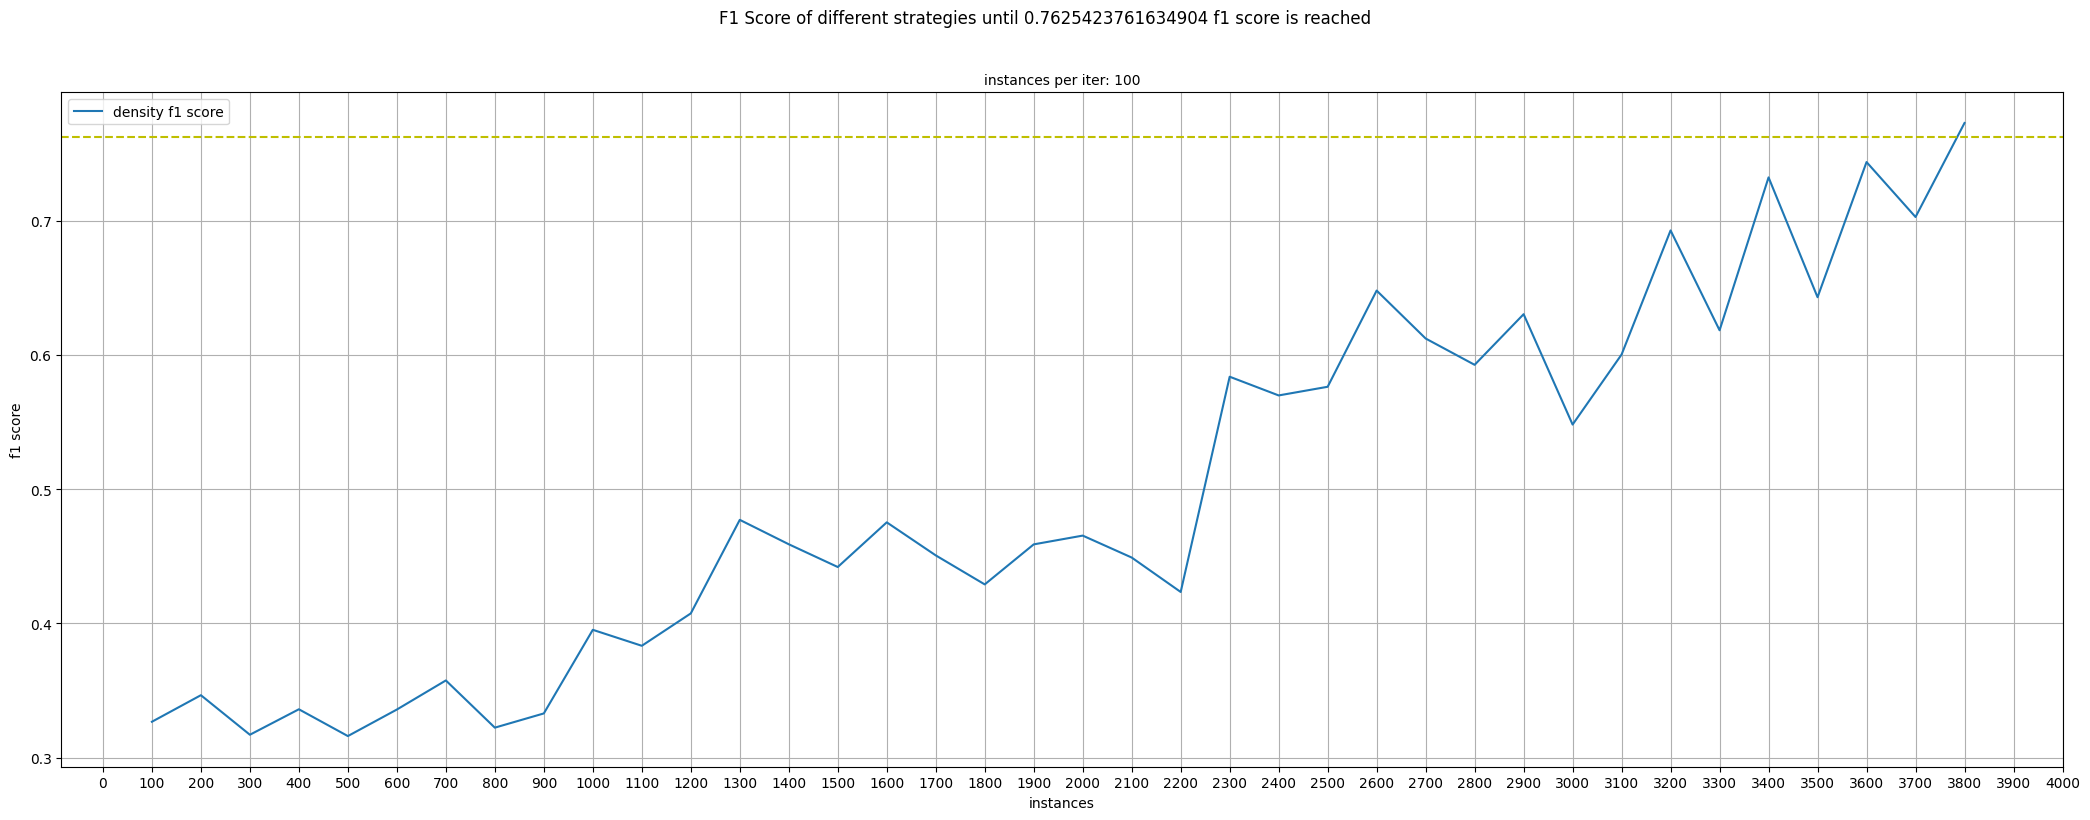

In [12]:
print(scores)


plot_results(
    scores,  # output data frame from strategy_comparison
    n_instances=n_instances,
    tot_samples=len(train_set),  # size of the original training set, for scale
    # goal_acc=goal_acc,
    figsize=(21, 8),
    goal_metric=goal_metric,
    goal_metric_val=goal_f1 if goal_metric == "f1" else goal_acc
)
